# 5-minute tour of `pycomlink`

This is a very brief overview of features available in the `pycomlink` package for processing Commercial Microwave Links (CMLs). A more comprehensive overview can be found in the `pycomlink` [documentation](https://pycomlink.readthedocs.io).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import pycomlink as pycml

/Users/chwala-c/miniforge3/envs/opensense_software_ecosystem_example/lib/python3.12/site-packages/pycomlink/io/examples.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Load example data

`pycomlink` ships with a small example dataset of a few CMLs. We load it and take a look at the data structure.

In [2]:
data_path = pycml.io.examples.get_example_data_path()
cmls = xr.open_dataset(data_path + '/example_cml_data.nc')

# Select a few CMLs to keep the example fast
cmls = cmls.isel(cml_id=[0, 10, 370])

# Remove outliers, compute total loss (tl) and interpolate missing values
cmls['tsl'] = cmls.tsl.where(cmls.tsl != 255.0)
cmls['rsl'] = cmls.rsl.where(cmls.rsl != -99.9)
cmls['tl'] = cmls.tsl - cmls.rsl
cmls['tl'] = cmls.tl.interpolate_na(dim='time', method='linear', max_gap='5min')
cmls

<xarray.Dataset> Size: 2MB
Dimensions:           (time: 15840, cml_id: 3, channel_id: 2)
Coordinates:
  * time              (time) datetime64[ns] 127kB 2018-05-10 ... 2018-05-20T2...
  * cml_id            (cml_id) <U3 36B '0' '10' '370'
    length            (cml_id) float64 24B 6.179 2.862 5.721
    site_a_latitude   (cml_id) float64 24B 58.26 58.05 57.89
    site_a_longitude  (cml_id) float64 24B 1.388 1.34 1.292
    site_b_latitude   (cml_id) float64 24B 58.25 58.04 57.83
    site_b_longitude  (cml_id) float64 24B 1.304 1.378 1.298
  * channel_id        (channel_id) <U9 72B 'channel_1' 'channel_2'
    frequency         (cml_id, channel_id) float64 48B 2.491e+10 ... 2.486e+10
    polarization      (cml_id, channel_id) <U1 24B 'V' 'V' 'V' 'V' 'V' 'V'
Data variables:
    rsl               (channel_id, cml_id, time) float64 760kB -47.0 ... -44.2
    tsl               (channel_id, cml_id, time) float64 760kB 13.0 ... 16.0
    tl                (channel_id, cml_id, time) float64 760kB 60.0 ... 60.2

The data follows the OpenSense naming conventions. Each CML has a `rsl` (received signal level) and `tsl` (transmitted signal level) time series. The total path attenuation `tl` is the difference between the two.

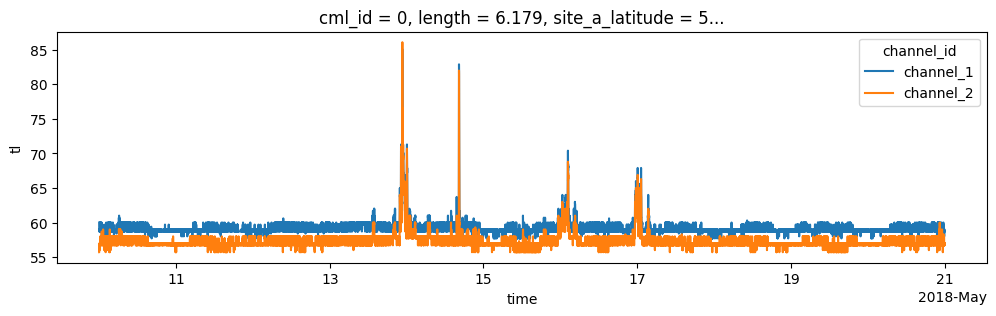

In [4]:
cmls['tl'] = cmls.tsl - cmls.rsl
cmls.tl.isel(cml_id=0).plot.line(x='time', figsize=(12, 3));

## Wet-dry classification

Before estimating rainfall, we need to know which time steps are affected by rain (wet) and which are not (dry). `pycomlink` provides several methods for this. Here we use a Multilayer Perceptron (MLP) trained on high-resolution weather radar data ([Øydvin et al. 2024](https://egusphere.copernicus.org/preprints/2024/egusphere-2024-647)). The MLP uses the total loss `tl` of both sublinks as input.

/Users/chwala-c/miniforge3/envs/opensense_software_ecosystem_example/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/chwala-c/miniforge3/envs/opensense_software_ecosystem_example/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


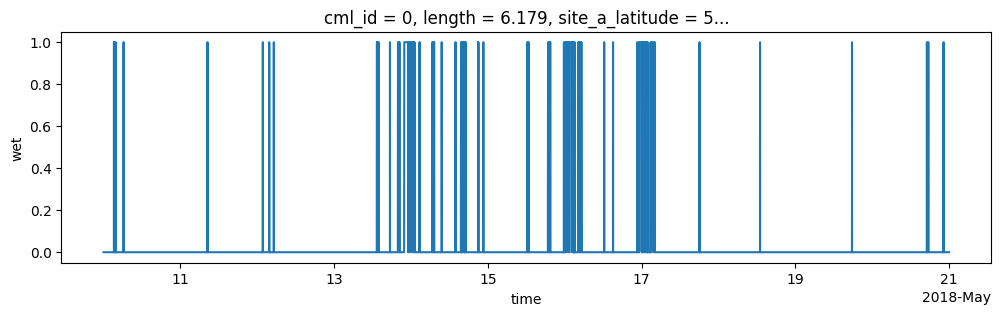

In [5]:
from pycomlink.processing.wet_dry import mlp

cmls['wet'] = (('cml_id', 'time'), np.zeros([cmls.cml_id.size, cmls.time.size]))
for cml_id in cmls.cml_id.values:
    mlp_out = mlp.mlp_wet_dry(
        trsl_channel_1=cmls.sel(cml_id=cml_id).isel(channel_id=0).tl,
        trsl_channel_2=cmls.sel(cml_id=cml_id).isel(channel_id=1).tl,
        model_sel='rad_online',
    )
    cmls['wet'].loc[{'cml_id': cml_id}] = np.argmax(mlp_out, axis=1)

cmls.wet.isel(cml_id=0).plot(figsize=(12, 3));

## Baseline determination

The baseline is the dry-weather signal level. We estimate it from the dry periods and subtract it from the total attenuation to get the rain-induced attenuation.

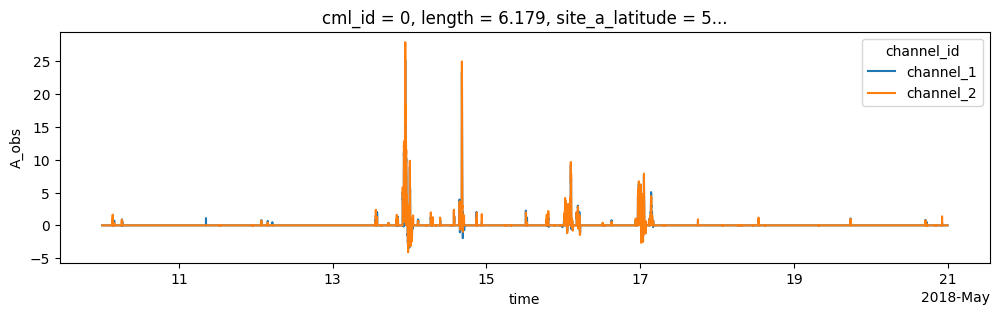

In [7]:
cmls['baseline'] = pycml.processing.baseline.baseline_constant(
    trsl=cmls.tl,
    wet=cmls.wet,
    n_average_last_dry=5,
)
cmls['A_obs'] = cmls.tl - cmls.baseline
cmls.A_obs.isel(cml_id=0).plot.line(x='time', figsize=(12, 3));

## Wet antenna attenuation

Water on the antenna attenuates the signal even without rain in the path. `pycomlink` provides a model to correct for this effect.

In [8]:
cmls['waa'] = pycml.processing.wet_antenna.waa_pastorek_2021_from_A_obs(
    A_obs=cmls.A_obs,
    f_Hz=cmls.frequency * 1e6,
    pol=cmls.polarization.data,
    L_km=cmls.length / 1000,
    A_max=6,
    zeta=0.7,
    d=0.15,
)
cmls['A'] = cmls.A_obs - cmls.waa
cmls.A.isel(cml_id=0).plot(figsize=(12, 3));

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (2, 3) and arg 2 with shape (3, 2).

## Rainfall estimation via the k-R relation

Finally, we convert the rain-induced attenuation to rain rate using the power-law k-R relation.

In [ ]:
cmls['R'] = pycml.processing.k_R_relation.calc_R_from_A(
    A=cmls.A,
    L_km=cmls.length.astype(float) / 1000,
    f_GHz=cmls.frequency / 1000,
    pol=cmls.polarization,
)
cmls.R.isel(cml_id=0).plot(figsize=(12, 3));

## Summary

That's the core CML processing chain in `pycomlink`: load data → wet-dry classification → baseline → wet antenna correction → k-R relation. Explore the [documentation](https://pycomlink.readthedocs.io) for more methods and options.